# Block 00: Setup and your first tool, a gradient checker

**Paper anchor:** none yet (tooling)
**Builds on:** Python and NumPy
**Time:** about 2 hours, in short sessions
**You will write:** `numerical_grad`
**Done when:** the checkpoint passes and you have the dataset on disk

> **How this notebook works.** Claude teaches each concept in chat, one step at a time (type `next`).
> You write every line of solution code, in the cells marked **YOUR CODE**. Checkpoint cells test behavior only
> and never contain a solution (please don't open `checks/` until you pass). Stuck or wrong? Paste your code and
> the output into chat: we find the misconception together. Log every mistake in the table at the bottom.

In [1]:
# provided: repo paths (works from notebooks/ locally and from the repo root on Colab)
import sys, pathlib
ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
for p in (ROOT, ROOT / "src"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import numpy as np
np.set_printoptions(precision=4, suppress=True)
from checks import b00

## 1. Environment check

In [2]:
# provided
import platform, numpy, matplotlib
print("python", platform.python_version(), "| numpy", numpy.__version__, "| matplotlib", matplotlib.__version__)
try:
    import torch
    print("torch", torch.__version__, "| CUDA available:", torch.cuda.is_available())
except ImportError:
    print("torch not installed yet (needed from block 07): pip install torch")

python 3.11.9 | numpy 2.2.6 | matplotlib 3.10.3
torch not installed yet (needed from block 07): pip install torch


## 2. Get the data
Tiny Shakespeare, about 1 MB of plain text. It stays out of git (see `.gitignore`).
Later notebooks find it through `minitransformer.paths`, so you never type its path by hand.

In [3]:
# provided plumbing (not part of the learning)
from minitransformer.paths import ensure_text
path = ensure_text()
text = path.read_text(encoding="utf-8")
print(f"{len(text):,} characters")
print(text[:300])

1,115,394 characters
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us


In [4]:
chars = sorted(set(text))
print(len(chars), "unique characters:", "".join(chars))

65 unique characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz


## 3. A numerical gradient checker
In blocks 03, 04 and 06 you derive gradients by hand. Hand derivations go wrong silently, so every one of them gets
compared with a numerical estimate. The derivative is a limit of difference quotients, so pick a small step
$\varepsilon$ and evaluate $f$ on both sides of each coordinate.

## Before you code
Answer in the cell below, in your own words. Guessing is fine; we check in chat.

1. For $f(x) = x^3$, expand $f(x+\varepsilon)$ and $f(x-\varepsilon)$ as Taylor series. What error does the one-sided quotient $(f(x+\varepsilon) - f(x))/\varepsilon$ have? What about the symmetric one?
2. Why can't you make $\varepsilon$ as small as you like in float64?
3. For an input with 10,000 numbers, how many calls to $f$ does the symmetric version need?

*My answers:*

1. 
2. 
3. 

In [5]:
import numpy as np

In [6]:
def f(x): 
    return x**3

In [7]:
# YOUR CODE: replace each `raise NotImplementedError` with your implementation

def numerical_grad(f, x, eps=1e-5):
    grad = np.zeros_like(x)
    for i in np.ndindex(x.shape):
        old = x[i]
        x[i] = old + eps
        f_plus = f(x)
        x[i] = old - eps
        f_minus = f(x)
        x[i] = old
        slope = (f_plus - f_minus) / (2 * eps)
        grad[i] = slope
    return grad

In [8]:
print(numerical_grad(lambda x: np.sum(x**2), np.array([1.0, 2.0, 3.0])))

[2. 4. 6.]


In [9]:
b00.check_numerical_grad(numerical_grad)

Checkpoint 00: numerical_grad
  PASS  returns an array with the same shape as x
  PASS  d/dx sum(x^2) = 2x
  PASS  works on 2-D arrays: d/dx sum(sin x) = cos x
  PASS  x is unchanged after the call
  PASS  d/dx (x^T A x) = (A + A^T) x  (cross terms handled)
  PASS  accurate even with a coarse eps = 1e-3 on sum(x^3): error ~ eps^2, not ~ eps
  All checks passed.



True

## 4. Mini-experiment: the best eps
**Hypothesis (numerical analysis, not from the paper):** for $f = \sin$ at $x = 1$, the error of your checker
falls as $\varepsilon^2$, then rises again once rounding error (about $10^{-16}/\varepsilon$) dominates.
**Falsified if** the log-log curve of error against $\varepsilon$ has no minimum between $10^{-1}$ and $10^{-12}$.
Predict where the minimum is before you run it.

In [10]:
# YOUR CODE: compute the error for eps in np.logspace(-1, -12, 23) and plot it on log-log axes

eps_values = np.logspace(-1,-12,23)
true_slope = np.cos(1.0)
errors = [] 
for i in eps_values: 
    est = numerical_grad(lambda x: np.sin(x[0]), np.array([1.0]), i)[0]
    err = np.abs(est - true_slope)
    errors.append(err)
    print(f"eps: {i:.1e}, est: {est:.6f}, true: {true_slope:.6f}, error: {err:.6e}")


eps: 1.0e-01, est: 0.539402, true: 0.540302, error: 9.000537e-04
eps: 3.2e-02, est: 0.540212, true: 0.540302, error: 9.004588e-05
eps: 1.0e-02, est: 0.540293, true: 0.540302, error: 9.004993e-06
eps: 3.2e-03, est: 0.540301, true: 0.540302, error: 9.005034e-07
eps: 1.0e-03, est: 0.540302, true: 0.540302, error: 9.005045e-08
eps: 3.2e-04, est: 0.540302, true: 0.540302, error: 9.005038e-09
eps: 1.0e-04, est: 0.540302, true: 0.540302, error: 9.004295e-10
eps: 3.2e-05, est: 0.540302, true: 0.540302, error: 8.892576e-11
eps: 1.0e-05, est: 0.540302, true: 0.540302, error: 1.114087e-11
eps: 3.2e-06, est: 0.540302, true: 0.540302, error: 6.005196e-13
eps: 1.0e-06, est: 0.540302, true: 0.540302, error: 2.771694e-11
eps: 3.2e-07, est: 0.540302, true: 0.540302, error: 1.815470e-11
eps: 1.0e-07, est: 0.540302, true: 0.540302, error: 1.943277e-10
eps: 3.2e-08, est: 0.540302, true: 0.540302, error: 1.815470e-11
eps: 1.0e-08, est: 0.540302, true: 0.540302, error: 2.581230e-09
eps: 3.2e-09, est: 0.5403

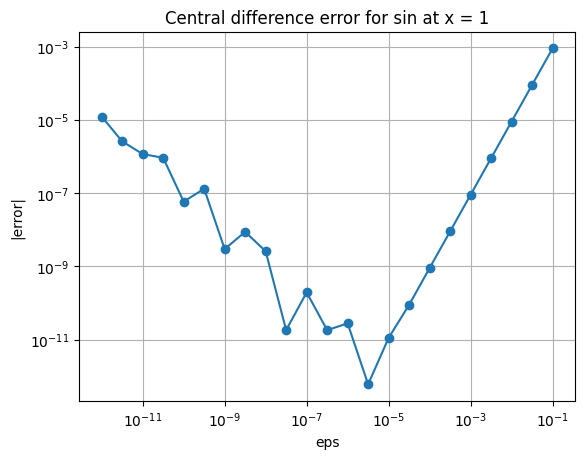

In [11]:
import matplotlib.pyplot as plt

plt.loglog(eps_values, errors, marker="o")
plt.xlabel("eps")
plt.ylabel("|error|")
plt.title("Central difference error for sin at x = 1")
plt.grid(True, which="both")
plt.show()

## Explain it back
Without notes. Then paste your answers into chat.

1. Why do we trust a finite-difference estimate more than a hand derivation?
2. Why the symmetric difference, and what is its error order?
3. What would make a correct analytic gradient disagree with your checker?

*My explanation:*

1. The reason that we trust a finite difference estimate is that it does not apply any rule that is error prone as long as f is computed correctly. With small eps-dependent error that we measured to be about 1e-11 at the best eps. 
2. The symmetric difference has error order 2 (error ≈ h²), while the one-sided difference has order 1 (error ≈ h). Nudging both up and down cancels the first-order error, so shrinking h by 10× shrinks the error by 100× instead of 10×. That makes it more accurate at the same h.
3. okay so with an integer, the nudge gets chopped off (for example, 1.001 -> 1 or worst case 0.999 -> 0) and then if we choose eps incorrectly, the errors might explode. Too small, rounding error, too big formula error.

## Mistakes log
Every wrong attempt is data. Copy finished rows into `journal/mistakes.md`.

| # | What I wrote | Symptom | The misconception | The fix |
|---|---|---|---|---|
| 1 | | | | |

## Graduate
Nothing to graduate: `numerical_grad` stays in your notebooks as a tool. Commit: `git commit -m "block 00: setup and gradient checker"`